In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
os.makedirs("reports", exist_ok=True)
os.makedirs("models", exist_ok=True)
print("libraries imported")

libraries imported


In [23]:
# Step 1 load Dataset
data = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
print("=" * 40)
print("DATASET OVERVIEW")
print("=" * 40)
print(data.head())
print("\nShape:", data.shape)
print("\nColumns:", data.columns.tolist())
print("\nMissing Values:\n", data.isnull().sum())


DATASET OVERVIEW
   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77         4200            NaN  
1         125/80 

In [24]:
# STEP 2: PREPROCESSING
# Clean column names
data.columns = data.columns.str.replace(" ", "")

# Fill missing values in Sleep Disorder
data["SleepDisorder"] = data["SleepDisorder"].fillna("None")

# Drop Person ID
data = data.drop("PersonID", axis=1)


In [25]:
# Split Blood Pressure into Systolic and Diastolic
data[["Systolic", "Diastolic"]] = data["BloodPressure"].str.split("/", expand=True)
data["Systolic"] = data["Systolic"].astype(int)
data["Diastolic"] = data["Diastolic"].astype(int)
data = data.drop("BloodPressure", axis=1)

print("\nAfter Preprocessing:")
print(data.head())
print("\nShape:", data.shape)

data.head(20)


After Preprocessing:
  Gender  Age            Occupation  SleepDuration  QualityofSleep  \
0   Male   27     Software Engineer            6.1               6   
1   Male   28                Doctor            6.2               6   
2   Male   28                Doctor            6.2               6   
3   Male   28  Sales Representative            5.9               4   
4   Male   28  Sales Representative            5.9               4   

   PhysicalActivityLevel  StressLevel BMICategory  HeartRate  DailySteps  \
0                     42            6  Overweight         77        4200   
1                     60            8      Normal         75       10000   
2                     60            8      Normal         75       10000   
3                     30            8       Obese         85        3000   
4                     30            8       Obese         85        3000   

  SleepDisorder  Systolic  Diastolic  
0          None       126         83  
1          None       

,Gender,Age,Occupation,SleepDuration,QualityofSleep,PhysicalActivityLevel,StressLevel,BMICategory,HeartRate,DailySteps,SleepDisorder,Systolic,Diastolic
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,None,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
5,Male,28,Software Engineer,5.9,4,30,8,Obese,85,3000,Insomnia,140,90
6,Male,29,Teacher,6.3,6,40,7,Obese,82,3500,Insomnia,140,90
7,Male,29,Doctor,7.8,7,75,6,Normal,70,8000,None,120,80
8,Male,29,Doctor,7.8,7,75,6,Normal,70,8000,None,120,80
9,Male,29,Doctor,7.8,7,75,6,Normal,70,8000,None,120,80


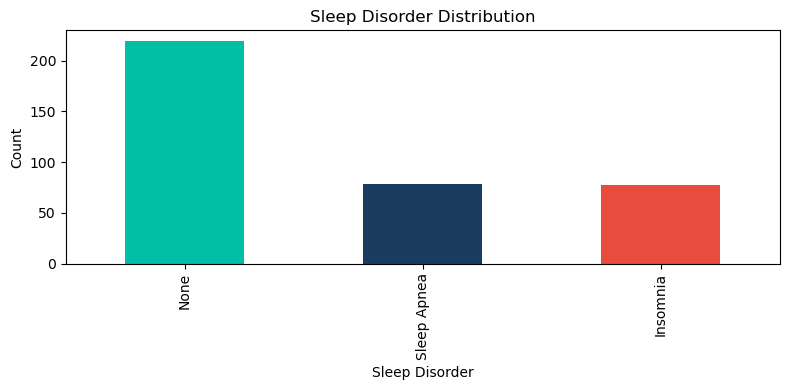

In [26]:
# STEP 3: EDA & VISUALIZATION
# Sleep Disorder Distribution
plt.figure(figsize=(8, 4))
data["SleepDisorder"].value_counts().plot(kind="bar", color=["#00BFA6", "#1a3c5e", "#e74c3c"])
plt.title("Sleep Disorder Distribution")
plt.xlabel("Sleep Disorder")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("reports/eda_sleep_disorder_distribution.png")
plt.show()


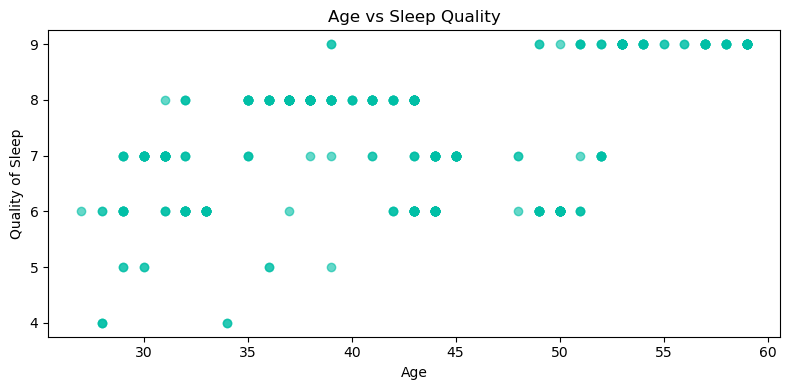

In [27]:
# Age vs Quality of Sleep
plt.figure(figsize=(8, 4))
plt.scatter(data["Age"], data["QualityofSleep"], color="#00BFA6", alpha=0.6)
plt.xlabel("Age")
plt.ylabel("Quality of Sleep")
plt.title("Age vs Sleep Quality")
plt.tight_layout()
plt.savefig("reports/eda_age_vs_sleep_quality.png")
plt.show()

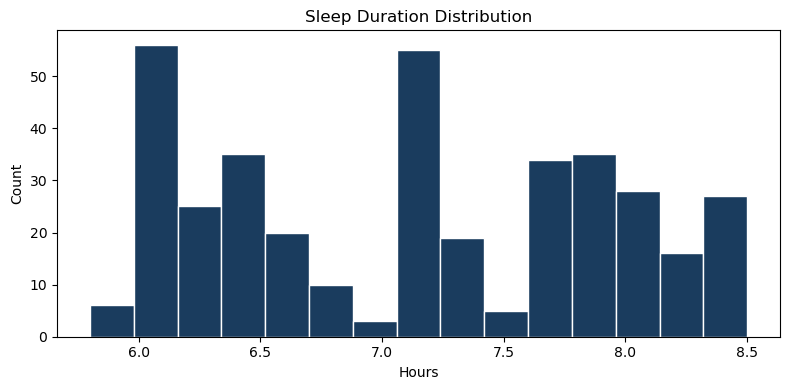

In [28]:
# Sleep Duration Distribution
plt.figure(figsize=(8, 4))
plt.hist(data["SleepDuration"], bins=15, color="#1a3c5e", edgecolor="white")
plt.title("Sleep Duration Distribution")
plt.xlabel("Hours")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("reports/eda_sleep_duration_distribution.png")
plt.show()


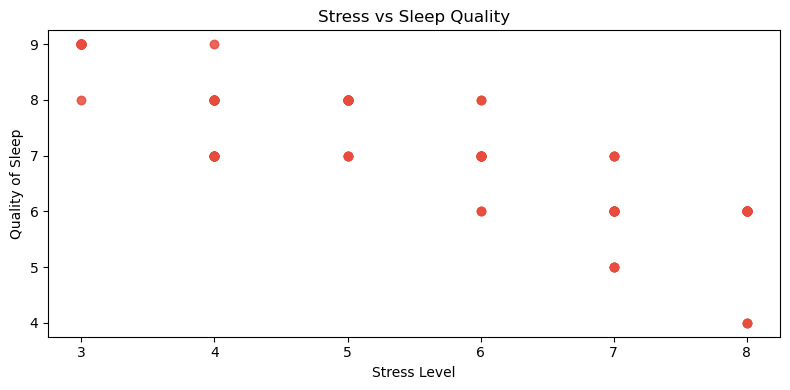

In [29]:
# Stress Level vs Sleep Quality
plt.figure(figsize=(8, 4))
plt.scatter(data["StressLevel"], data["QualityofSleep"], color="#e74c3c", alpha=0.6)
plt.xlabel("Stress Level")
plt.ylabel("Quality of Sleep")
plt.title("Stress vs Sleep Quality")
plt.tight_layout()
plt.savefig("reports/eda_stress_vs_sleep_quality.png")
plt.show()

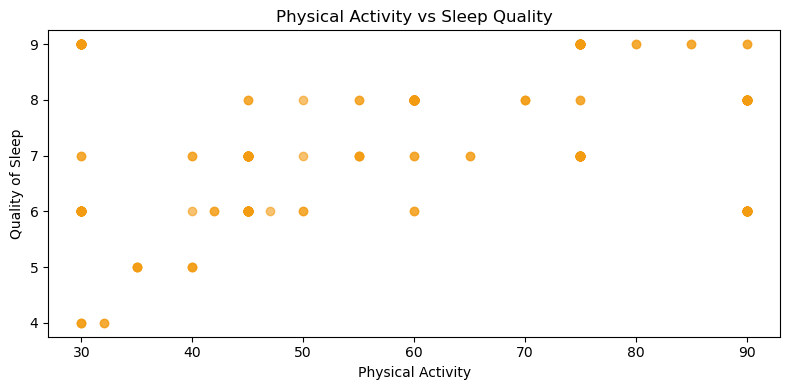

In [30]:
# Physical Activity vs Sleep Quality
plt.figure(figsize=(8, 4))
plt.scatter(data["PhysicalActivityLevel"], data["QualityofSleep"], color="#f39c12", alpha=0.6)
plt.xlabel("Physical Activity")
plt.ylabel("Quality of Sleep")
plt.title("Physical Activity vs Sleep Quality")
plt.tight_layout()
plt.savefig("reports/eda_activity_vs_sleep_quality.png")
plt.show()

In [31]:
# STEP 4: ENCODING
# Gender
data["Gender"] = data["Gender"].map({"Male": 0, "Female": 1})

# Sleep Disorder
data["SleepDisorder"] = data["SleepDisorder"].map({
    "None": 0,
    "Insomnia": 1,
    "Sleep Apnea": 2
})

# Occupation + BMI (One-Hot Encoding)
data = pd.get_dummies(data, columns=["Occupation", "BMICategory"], drop_first=True)

# Convert bool to int
bool_cols = data.select_dtypes(include=["bool"]).columns
data[bool_cols] = data[bool_cols].astype(int)

print("\nAfter Encoding:")
print(data.head())
print("Shape:", data.shape)




After Encoding:
   Gender  Age  SleepDuration  QualityofSleep  PhysicalActivityLevel  \
0       0   27            6.1               6                     42   
1       0   28            6.2               6                     60   
2       0   28            6.2               6                     60   
3       0   28            5.9               4                     30   
4       0   28            5.9               4                     30   

   StressLevel  HeartRate  DailySteps  SleepDisorder  Systolic  ...  \
0            6         77        4200              0       126  ...   
1            8         75       10000              0       125  ...   
2            8         75       10000              0       125  ...   
3            8         85        3000              2       140  ...   
4            8         85        3000              2       140  ...   

   Occupation_Manager  Occupation_Nurse  Occupation_Sales Representative  \
0                   0                 0        

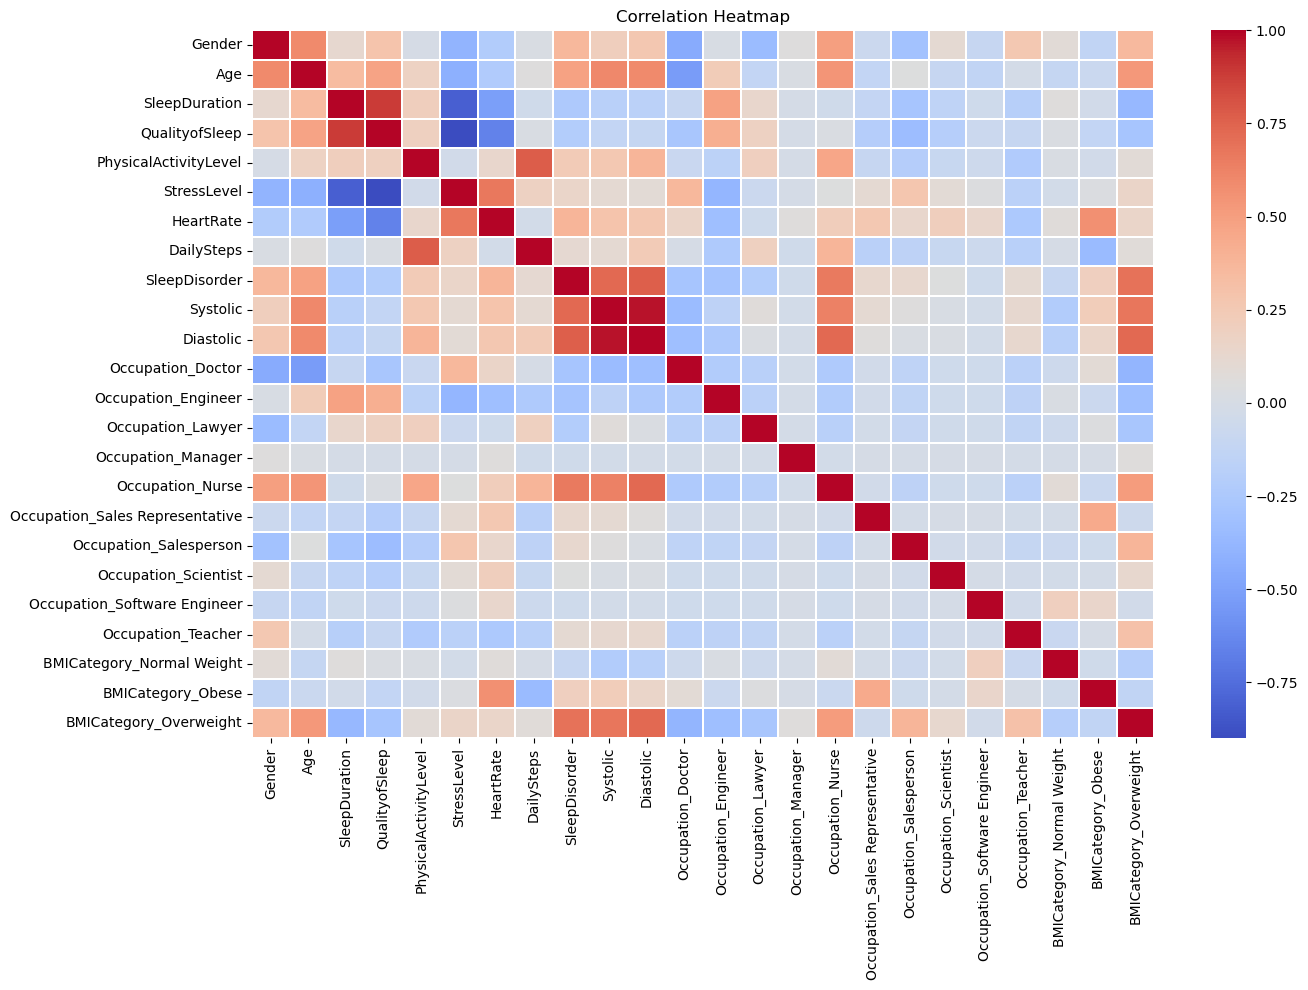

In [32]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(data.corr(), cmap="coolwarm", annot=False, linewidths=0.3)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("reports/eda_correlation_heatmap.png")
plt.show()



In [33]:
# STEP 5: FEATURE / TARGET SPLIT
# Model 1 - Regression (Sleep Quality)
y1 = data["QualityofSleep"]
x1 = data.drop(["QualityofSleep"], axis=1)

# Model 2 - Classification (Sleep Disorder)
y2 = data["SleepDisorder"]
x2 = data.drop(["SleepDisorder"], axis=1)


In [34]:
# STEP 6: TRAIN-TEST SPLIT
from sklearn.model_selection import train_test_split, cross_val_score

x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, test_size=0.2, random_state=42)
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.2, random_state=42)



REGRESSION MODELS - Sleep Quality Prediction

Linear Regression:
  R2 Score : 0.9670
  MSE      : 0.0497

Random Forest Regressor:
  R2 Score : 0.9841
  MSE      : 0.0240
  CV R2    : 0.7248 ± 0.2282


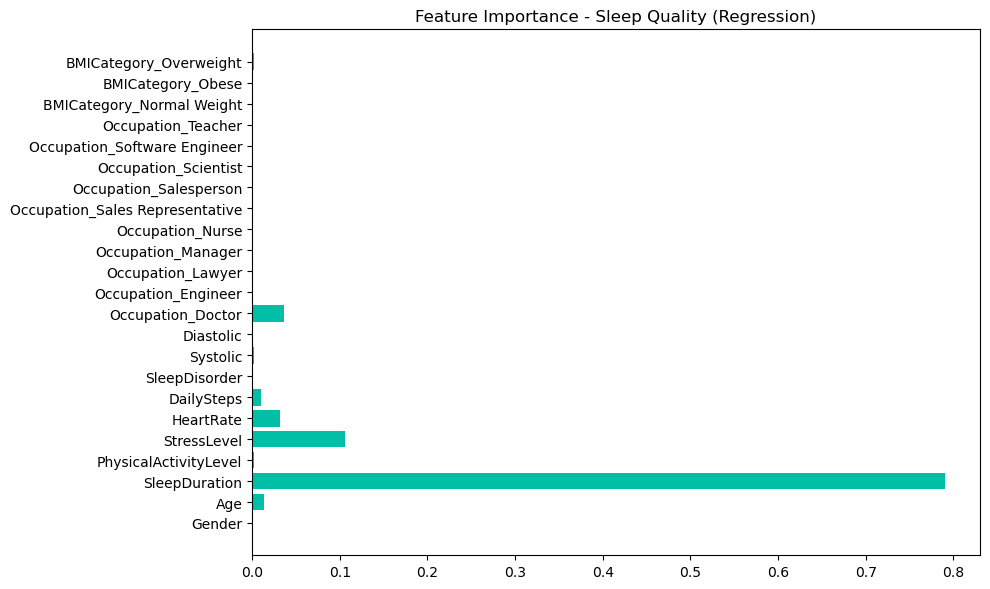


ANN Regressor:
  R2 Score : 0.9327
  MSE      : 0.1016


In [35]:
# STEP 7: REGRESSION MODELS (Sleep Quality)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

print("\n" + "=" * 60)
print("REGRESSION MODELS - Sleep Quality Prediction")
print("=" * 60)

# --- Linear Regression ---
slr = LinearRegression()
slr.fit(x1_train, y1_train)
y1_pred_lr = slr.predict(x1_test)
lr_r2 = r2_score(y1_test, y1_pred_lr)
lr_mse = mean_squared_error(y1_test, y1_pred_lr)
print(f"\nLinear Regression:")
print(f"  R2 Score : {lr_r2:.4f}")
print(f"  MSE      : {lr_mse:.4f}")

# --- Random Forest Regressor ---
rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfr.fit(x1_train, y1_train)
y1_pred_rfr = rfr.predict(x1_test)
rfr_r2 = r2_score(y1_test, y1_pred_rfr)
rfr_mse = mean_squared_error(y1_test, y1_pred_rfr)
print(f"\nRandom Forest Regressor:")
print(f"  R2 Score : {rfr_r2:.4f}")
print(f"  MSE      : {rfr_mse:.4f}")

# Cross-validation
cv_rfr = cross_val_score(rfr, x1, y1, cv=5, scoring="r2")
print(f"  CV R2    : {cv_rfr.mean():.4f} ± {cv_rfr.std():.4f}")

# Feature Importance - Regression
plt.figure(figsize=(10, 6))
importances_r = rfr.feature_importances_
plt.barh(x1_train.columns, importances_r, color="#00BFA6")
plt.title("Feature Importance - Sleep Quality (Regression)")
plt.tight_layout()
plt.savefig("reports/feature_importance_regression.png")
plt.show()

# --- ANN Regressor ---
scaler_r = StandardScaler()
x1_train_scaled = scaler_r.fit_transform(x1_train)
x1_test_scaled = scaler_r.transform(x1_test)

ann_reg = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
ann_reg.fit(x1_train_scaled, y1_train)
y1_pred_ann = ann_reg.predict(x1_test_scaled)
ann_r2 = r2_score(y1_test, y1_pred_ann)
ann_mse = mean_squared_error(y1_test, y1_pred_ann)
print(f"\nANN Regressor:")
print(f"  R2 Score : {ann_r2:.4f}")
print(f"  MSE      : {ann_mse:.4f}")




CLASSIFICATION MODELS - Sleep Disorder Prediction

KNN Classifier:
  Accuracy : 0.8667
  Confusion Matrix:
[[41  2  0]
 [ 1 14  1]
 [ 1  5 10]]

Random Forest Classifier:
  Accuracy : 0.8800
  Confusion Matrix:
[[42  1  0]
 [ 1 13  2]
 [ 1  4 11]]

Classification Report:
              precision    recall  f1-score   support

        None       0.95      0.98      0.97        43
    Insomnia       0.72      0.81      0.76        16
 Sleep Apnea       0.85      0.69      0.76        16

    accuracy                           0.88        75
   macro avg       0.84      0.83      0.83        75
weighted avg       0.88      0.88      0.88        75

  CV Accuracy : 0.7409 ± 0.1488


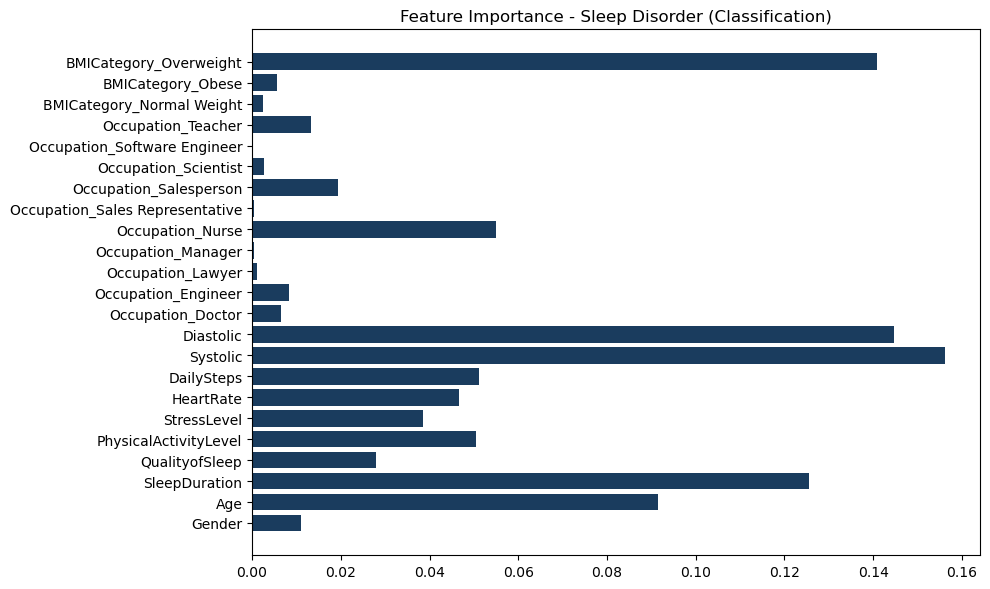


ANN Classifier:
  Accuracy : 0.8933


In [36]:
# STEP 8: CLASSIFICATION MODELS (Sleep Disorder)
# ---------------------------------------------------
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("\n" + "=" * 60)
print("CLASSIFICATION MODELS - Sleep Disorder Prediction")
print("=" * 60)

# --- KNN ---
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x2_train, y2_train)
y2_pred_knn = knn.predict(x2_test)
knn_acc = accuracy_score(y2_test, y2_pred_knn)
print(f"\nKNN Classifier:")
print(f"  Accuracy : {knn_acc:.4f}")
print(f"  Confusion Matrix:\n{confusion_matrix(y2_test, y2_pred_knn)}")

# --- Random Forest Classifier ---
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(x2_train, y2_train)
y2_pred_rfc = rfc.predict(x2_test)
rfc_acc = accuracy_score(y2_test, y2_pred_rfc)
print(f"\nRandom Forest Classifier:")
print(f"  Accuracy : {rfc_acc:.4f}")
print(f"  Confusion Matrix:\n{confusion_matrix(y2_test, y2_pred_rfc)}")
print(f"\nClassification Report:\n{classification_report(y2_test, y2_pred_rfc, target_names=['None','Insomnia','Sleep Apnea'])}")

# Cross-validation
cv_rfc = cross_val_score(rfc, x2, y2, cv=5, scoring="accuracy")
print(f"  CV Accuracy : {cv_rfc.mean():.4f} ± {cv_rfc.std():.4f}")

# Feature Importance - Classification
plt.figure(figsize=(10, 6))
importances_c = rfc.feature_importances_
plt.barh(x2_train.columns, importances_c, color="#1a3c5e")
plt.title("Feature Importance - Sleep Disorder (Classification)")
plt.tight_layout()
plt.savefig("reports/feature_importance_classification.png")
plt.show()

# --- ANN Classifier ---
scaler_c = StandardScaler()
x2_train_scaled = scaler_c.fit_transform(x2_train)
x2_test_scaled = scaler_c.transform(x2_test)

ann_clf = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
ann_clf.fit(x2_train_scaled, y2_train)
y2_pred_ann = ann_clf.predict(x2_test_scaled)
ann_clf_acc = accuracy_score(y2_test, y2_pred_ann)
print(f"\nANN Classifier:")
print(f"  Accuracy : {ann_clf_acc:.4f}")



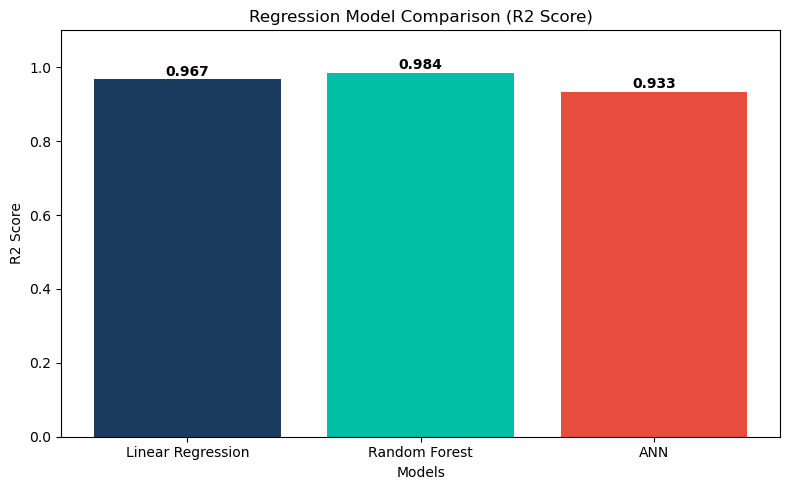

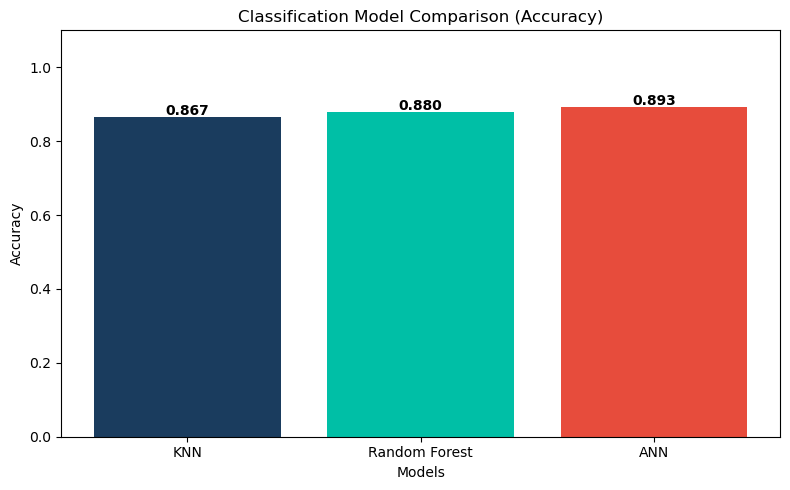

In [37]:
# STEP 9: MODEL COMPARISON GRAPHS
# ---------------------------------------------------

# Regression R2 Comparison
reg_models = ["Linear Regression", "Random Forest", "ANN"]
reg_scores = [lr_r2, rfr_r2, ann_r2]

plt.figure(figsize=(8, 5))
bars = plt.bar(reg_models, reg_scores, color=["#1a3c5e", "#00BFA6", "#e74c3c"])
for bar, score in zip(bars, reg_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{score:.3f}", ha="center", fontsize=10, fontweight="bold")
plt.title("Regression Model Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.ylim(0, 1.1)
plt.tight_layout()
plt.savefig("reports/comparison_regression.png")
plt.show()

# Classification Accuracy Comparison
clf_models = ["KNN", "Random Forest", "ANN"]
clf_scores = [knn_acc, rfc_acc, ann_clf_acc]

plt.figure(figsize=(8, 5))
bars = plt.bar(clf_models, clf_scores, color=["#1a3c5e", "#00BFA6", "#e74c3c"])
for bar, score in zip(bars, clf_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{score:.3f}", ha="center", fontsize=10, fontweight="bold")
plt.title("Classification Model Comparison (Accuracy)")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)
plt.tight_layout()
plt.savefig("reports/comparison_classification.png")
plt.show()


In [38]:
# STEP 10: SAVE BEST MODELS & SCALERS
# ---------------------------------------------------
if not os.path.exists("models"):
    os.makedirs("models")

# Save best regression model (Random Forest)
joblib.dump(rfr, "models/sleep_quality_model.pkl")
joblib.dump(scaler_r, "models/scaler_regression.pkl")

# Save best classification model (Random Forest)
joblib.dump(rfc, "models/sleep_disorder_model.pkl")
joblib.dump(scaler_c, "models/scaler_classification.pkl")

# Save column names for app.py to use
joblib.dump(list(x1_train.columns), "models/regression_columns.pkl")
joblib.dump(list(x2_train.columns), "models/classification_columns.pkl")

print("\n" + "=" * 60)
print("MODELS SAVED SUCCESSFULLY")
print("=" * 60)
print("  models/sleep_quality_model.pkl")
print("  models/sleep_disorder_model.pkl")
print("  models/scaler_regression.pkl")
print("  models/scaler_classification.pkl")
print("  models/regression_columns.pkl")
print("  models/classification_columns.pkl")




MODELS SAVED SUCCESSFULLY
  models/sleep_quality_model.pkl
  models/sleep_disorder_model.pkl
  models/scaler_regression.pkl
  models/scaler_classification.pkl
  models/regression_columns.pkl
  models/classification_columns.pkl


In [39]:
# STEP 11: QUICK TEST PREDICTIONS
# ---------------------------------------------------
print("\n" + "=" * 60)
print("SAMPLE PREDICTIONS")
print("=" * 60)

# Use first test row as sample
sample_q = x1_test.iloc[[0]]
pred_quality = rfr.predict(sample_q)
print(f"\nSample Sleep Quality Prediction : {pred_quality[0]:.2f} / 10")

sample_d = x2_test.iloc[[0]]
pred_disorder = rfc.predict(sample_d)
labels = {0: "No Disorder", 1: "Insomnia", 2: "Sleep Apnea"}
print(f"Sample Sleep Disorder Prediction: {labels[pred_disorder[0]]}")

print("\n✅ main.py completed successfully!")
print("Run app.py next: streamlit run app.py")


SAMPLE PREDICTIONS

Sample Sleep Quality Prediction : 9.00 / 10
Sample Sleep Disorder Prediction: No Disorder

✅ main.py completed successfully!
Run app.py next: streamlit run app.py
